# Requirements

## Install required libraries

In [2]:
# !pip install hazm
# !pip install stopwords_guilannlp
# !pip install pandas
# !pip install tensorflow
# # !pip install keras

## Import Libraries

In [4]:
# General
import numpy as np
import pandas as pd
import codecs
# Keras
from keras import optimizers
from keras.models import Model, Sequential
from keras.layers import Dense, Input, Embedding, Dropout
from keras.layers import GlobalMaxPool1D, MaxPooling1D, GlobalMaxPooling1D
from keras.layers import LSTM, Bidirectional
from keras.layers import Conv1D
from keras.utils import plot_model
from keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
# Preprocessing
from stopwords_guilannlp import stopwords_output
from hazm import *
# Visualization
%matplotlib inline
import matplotlib.pyplot as plt
from keras.utils import plot_model
# Measuring metrics
from sklearn.metrics import f1_score

In [5]:
import tensorflow as tf
print(tf.__version__)


2.15.1



# Import & Analyze Dataset

In [7]:
test = pd.read_csv('./binary/Dataset/test.csv', index_col=None, header=None, encoding="utf-8")

In [8]:
x_test = test[0]
y_test = test[1]

In [9]:
print('Number of testing sentence: ', x_test.shape)
print('Number of testing label: ', y_test.shape)

Number of testing sentence:  (1854,)
Number of testing label:  (1854,)


In [10]:
binary_y_test = []
binary_x_test = []
for i, y in enumerate(y_test):
  if int(y) != 0:
    if int(y) > 0:
      binary_y_test.append(1)
      binary_x_test.append(x_test[i])
    else:
      binary_y_test.append(0)
      binary_x_test.append(x_test[i])

In [11]:
x_test = np.asarray(binary_x_test)
y_test = np.asarray(binary_y_test)


In [12]:
original = pd.read_csv('./Dataset/original.csv', index_col=None, header=None, encoding="utf-8")
balanced = pd.read_csv('./Dataset/balanced.csv', index_col=None, header=None, encoding="utf-8")
translation = pd.read_csv('./Dataset/translation.csv', index_col=None, header=None, encoding="utf-8")

In [13]:
selected_dataset = translation

In [14]:
selected_dataset = selected_dataset.sample(frac=1).reset_index(drop=True)

In [15]:
x_train = selected_dataset[0]
y_train = selected_dataset[1]

In [16]:
print('Number of training sentence: ', x_train.shape)
print('Number of training label: ', y_train.shape)

Number of training sentence:  (14046,)
Number of training label:  (14046,)


In [17]:
binary_y_train = []
binary_x_train = []
for i, y in enumerate(y_train):
  if int(y) != 0:
    if int(y) > 0:
      binary_y_train.append(1)
      binary_x_train.append(x_train[i])
    else:
      binary_y_train.append(0)
      binary_x_train.append(x_train[i])

In [18]:
# Convert dataframes to numpy arrays
x_train = np.asarray(binary_x_train)
y_train = np.asarray(binary_y_train)

In [19]:
# See the data number of sentence in each category
from collections import Counter
cnt = Counter(y_train)
cnt = dict(cnt)
print(cnt)

{1: 7856, 0: 2190}


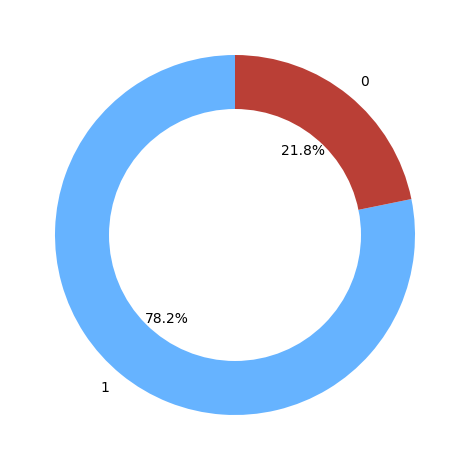

In [23]:
labels = list(cnt.keys())
sizes = list(cnt.values())
colors = ['#66b3ff', '#ba3f36','#ffcc99','#ff9999', '#a4a444']
fig1, ax1 = plt.subplots()
ax1.pie(sizes, labels=labels, colors=colors,
        autopct='%1.1f%%', startangle=90)

centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

ax1.axis()
plt.tight_layout()

# plt.savefig('distribution.png')
plt.show()

# Preprocess

In [18]:
puncs = ['،', '.', ',', ':', ';', '"']
normalizer = Normalizer()
lemmatizer = Lemmatizer()

# turn a doc into clean tokens
def clean_doc(doc):
    doc = normalizer.normalize(doc) # Normalize document using Hazm Normalizer
    tokenized = word_tokenize(doc)  # Tokenize text
    tokens = []
    for t in tokenized:
      temp = t
      for p in puncs:
        temp = temp.replace(p, '')
      tokens.append(temp)
    # tokens = [w for w in tokens if not w in stop_set]    # Remove stop words
    tokens = [w for w in tokens if not len(w) <= 1]
    tokens = [w for w in tokens if not w.isdigit()]
    tokens = [lemmatizer.lemmatize(w) for w in tokens] # Lemmatize sentence words
    tokens = ' '.join(tokens)
    return tokens

# Prepare data for Deep Learning model

## Apply preprocessing to data

In [19]:
# Apply preprocessing step to training data
train_docs = np.empty_like(x_train)
for index, document in enumerate(x_train):
  train_docs[index] = clean_doc(document)

In [20]:
# Applying preprocessing step to test data
test_docs = np.empty_like(x_test)
for index, document in enumerate(x_test):
  test_docs[index] = clean_doc(document)

## Setting tokenizer up

In [21]:
num_words = 2500

# Create the tokenizer
tokenizer = Tokenizer()

# fFt the tokenizer on the training documents
tokenizer.fit_on_texts(train_docs)

In [23]:
# Find maximum length of training sentences
max_length = max([len(s.split()) for s in train_docs])

## Embed sentences

In [24]:
# Embed training sequences
encoded_docs = tokenizer.texts_to_sequences(train_docs)

# Pad embeded training sequences
x_train_padded = pad_sequences(encoded_docs, maxlen=max_length, padding='post')

In [25]:
# Define vocabulary size (largest integer value)
vocab_size = len(tokenizer.word_index)

In [26]:
# Embed testing sequences
encoded_docs = tokenizer.texts_to_sequences(test_docs)
# Pad testing sequences
x_test_padded = pad_sequences(encoded_docs, maxlen=max_length, padding='post')

In [29]:
import pickle

# Save the tokenizer to file for later use in predicting sentiment of new text
with open('./tokenizer.pkl', 'wb') as file:
    pickle.dump(tokenizer, file)

# Deep Learning Models

## B-LSTM Model

In [32]:
# the lstm structure for binary classification
model_blstm = Sequential()
model_blstm.add(Embedding(vocab_size+1, 300, input_length=max_length))
#model_blstm.add(Bidirectional(CuDNNLSTM(300, return_sequences=True, name='lstm_layer'))) # when using GPU
model_blstm.add(Bidirectional(LSTM(int(300/2), activation='tanh', return_sequences=True), merge_mode='concat')) # when using CPU
model_blstm.add(GlobalMaxPool1D())
model_blstm.add(Dropout(0.2))
model_blstm.add(Dense(500, activation="relu"))
model_blstm.add(Dropout(0.1))
model_blstm.add(Dense(1, activation='sigmoid'))

In [33]:
model_blstm.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

model_blstm.summary()
batch_size_blstm = 32
epochs_blstm = 3


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 254, 300)          2012100   
                                                                 


 bidirectional (Bidirection  (None, 254, 300)          541200    
 al)                                                             
                                                                 
 global_max_pooling1d (Glob  (None, 300)               0         
 alMaxPooling1D)                                                 
                                                                 
 dropout (Dropout)           (None, 300)               0         
                                                                 
 dense (Dense)               (None, 500)               150500    
                                                                 
 dropout_1 (Dropout)         (None, 500)               0         
                                                                 
 dense_1 (Dense)             (None, 1)                 501       
                                                                 
Total params: 2704301 (10.32 MB)
Trainable params: 2704301 (10.32 MB)
Non-tr

In [34]:
# Train model
hist_blstm = model_blstm.fit(x_train_padded, y_train, batch_size=batch_size_blstm, epochs=epochs_blstm, shuffle=True, validation_data=(x_test_padded, y_test))

Epoch 1/3


314/314 [==============================] - 252s 783ms/step - loss: 0.3791 - accuracy: 0.8322 - val_loss: 0.2503 - val_accuracy: 0.8938
Epoch 2/3
314/314 [==============================] - 236s 753ms/step - loss: 0.2083 - accuracy: 0.9170 - val_loss: 0.2266 - val_accuracy: 0.9118
Epoch 3/3
314/314 [==============================] - 272s 866ms/step - loss: 0.1233 - accuracy: 0.9549 - val_loss: 0.2582 - val_accuracy: 0.9136


In [35]:
# Evaluate model
loss_blstm, acc_blstm = model_blstm.evaluate(x_test_padded, y_test, verbose=0)
print('Test Accuracy: %f' % (acc_blstm*100))

Test Accuracy: 91.359138


In [36]:
# Get prediction label
predict_x=model_blstm.predict(x_test_padded)
y_pred_blstm = (predict_x > 0.5).astype(int)


35/35 [==============================] - 6s 144ms/step
